# Comparaison des points GEE

Ce notebook charge et affiche **deux jeux de points** sur la même carte pour les comparer :

- 🔴 **Rouge** : les points uniques du KML Google Earth (sondes/canons/robots)
- 🔵 **Bleu** : les points agrégés du CSV `probes_2025.csv` avec eps=0.01 (taille ∝ nombre de mesures)

---

## 🔑 Étape 1 : Authentification GEE (à faire une seule fois)

La première fois, exécutez la cellule suivante pour vous authentifier. Un lien s'ouvre dans le navigateur ; autorisez l'accès et copiez le code de vérification dans le terminal.

In [5]:
%pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached xyzservices-2026.3.0-py3-none-any.whl.metadata (4.1 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Using cached xyzservices-2026.3.0-py3-none-any.whl (94 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]2m1/3 [branca]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import ee
# Authentification GEE (à faire une seule fois)
try:
    ee.Initialize(project="projet-hrms")
    print('GEE déjà initialisé ✓')
except Exception as e:
    print('Initialisation à faire :', e)
    # Dans un terminal : exécuter 'earthengine authenticate' puis relancer
    ee.Authenticate()
    ee.Initialize(project="projet-hrms")
    print('GEE authentifié et initialisé ✓')

GEE déjà initialisé ✓


---

## 📦 Étape 2 : Définition des deux jeux de points

Les coordonnées sont intégrées directement (extraites du KML Google Earth et du CSV `probes_2025.csv`).

In [7]:
_eps = 0.01

In [8]:
# --- Points du KML Google Earth (rouge) ---
kml_points = [
    [49.4734105, 2.6209064, "Canon 1"], [49.473197, 2.620721, "Canon 2"],
    [49.4729482, 2.6204031, "Canon 3"], [49.4726711, 2.6200349, "Robot"],
    [49.4724608, 2.6196134, "Robot -20"], [49.4722075, 2.6200618, "Sec"],
    [49.4724934, 2.6196774, "Robot -20 2"], [49.4722723, 2.6200646, "Sec 2"],
    [49.4727479, 2.6200888, "Robot 2"], [50.0744007, 2.8127523, "Robot N"],
    [50.0735305, 2.811392, "Témoin sec"], [50.07334, 2.8119045, "Robot -30"],
    [50.0731835, 2.8110383, "Robot -15"], [50.072866, 2.8104762, "Robot"],
    [50.07159514283304, 2.810840921988427, "Canon"],
    [50.07115681528224, 2.813144409845645, "Canon -15"],
    [50.07074692532636, 2.814484578865744, "Canon -30"],
    [50.07192130183158, 2.81264868916512, "Robot"],
    [50.0724351926235, 2.813145149842529, "Robot -15"],
    [50.07279946370095, 2.813486988633722, "Robot -30"],
    [50.07325904418475, 2.811566802728043, "Témoin sec"],
    [50.07380313273988, 2.81433365161037, "Robot -15 + Azote"],
    [49.77665170110849, 3.100302718056547, "Sec"],
    [49.77654357347835, 3.100022559380988, "robot -20"],
    [49.77639599039765, 3.099734327870169, "robot"],
    [49.77618020813285, 3.099236754895067, "rampe"],
]

# --- Points du CSV probes_2025 (bleu, eps=0.01) : calcul direct ---
import pandas as pd
import numpy as np

_csv_2025_path = "/home/theodore/Téléchargements/Sondes/probes_2025.csv"
_df25 = pd.read_csv(_csv_2025_path)
_df25 = _df25[["latitude", "longitude"]].dropna()
_df25 = _df25[(_df25["longitude"] != 0) | (_df25["latitude"] != 0)]

_centers25, _counts25 = [], []
for _p in _df25[["latitude", "longitude"]].values:
    if _centers25 and np.min(np.linalg.norm(np.array(_centers25) - _p, axis=1)) <= _eps:
        _counts25[np.argmin(np.linalg.norm(np.array(_centers25) - _p, axis=1))] += 1
    else:
        _centers25.append(list(_p)); _counts25.append(1)

csv_points = [
    {"lat": float(la), "lon": float(lo), "count": int(n)}
    for (la, lo), n in sorted(zip(_centers25, _counts25), key=lambda x: -x[1])
]

print("Liste des points agrégés CSV 2025 (eps=0.01) :")
for p in csv_points:
    print(p)
# --- Points du CSV probes_2024 (bleu, eps=0.01) : calcul direct ---
import pandas as pd
import numpy as np

_csv_2024_path = "/home/theodore/Téléchargements/Sondes/probes_2024.csv"
_df24 = pd.read_csv(_csv_2024_path)
_df24 = _df24[["latitude", "longitude"]].dropna()
_df24 = _df24[(_df24["longitude"] != 0) | (_df24["latitude"] != 0)]

_eps = 0.01
_centers, _counts = [], []
for _p in _df24[["latitude", "longitude"]].values:
    if _centers and np.min(np.linalg.norm(np.array(_centers) - _p, axis=1)) <= _eps:
        _counts[np.argmin(np.linalg.norm(np.array(_centers) - _p, axis=1))] += 1
    else:
        _centers.append(list(_p)); _counts.append(1)

csv_points_2024 = [
    {"lat": float(la), "lon": float(lo), "count": int(n)}
    for (la, lo), n in sorted(zip(_centers, _counts), key=lambda x: -x[1])
]

# Affichage de la liste
print("Liste des points agrégés CSV 2024 (eps=0.01) :")
for p in csv_points_2024:
    print(p)


Liste des points agrégés CSV 2025 (eps=0.01) :
{'lat': 49.472972, 'lon': 2.6204094, 'count': 78286}
{'lat': 50.0744086, 'lon': 2.8128737, 'count': 52765}
{'lat': 49.4540862, 'lon': 2.5872307, 'count': 4500}
{'lat': 49.5133889, 'lon': 3.5255942, 'count': 384}
{'lat': 50.1628387, 'lon': 2.5580329, 'count': 384}
{'lat': 50.553449, 'lon': 2.7851709, 'count': 301}
{'lat': 49.6077595, 'lon': 2.2896283, 'count': 96}
{'lat': 50.2820728, 'lon': 1.7707874, 'count': 96}
{'lat': 50.5459287, 'lon': 2.8205363, 'count': 13}
{'lat': 49.6466401, 'lon': 2.5675357, 'count': 5}
Liste des points agrégés CSV 2024 (eps=0.01) :
{'lat': 49.5350146, 'lon': 2.680074, 'count': 74251}
{'lat': 50.0691821, 'lon': 2.3375673, 'count': 62605}
{'lat': 50.5449871, 'lon': 2.8183137, 'count': 2492}
{'lat': 49.5693351, 'lon': 2.5639271, 'count': 104}


---

## 🗺️ Étape 3 : Construction des FeatureCollections ee et carte interactive

In [9]:
import folium

# FeatureCollection rouge : points KML avec le nom
fc_kml = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([lon, lat]), {"name": name})
    for lat, lon, name in kml_points
])

# FeatureCollection bleue : points CSV avec count
fc_csv = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([p["lon"], p["lat"]]), {"count": p["count"]})
    for p in csv_points
])

print('KML :', fc_kml.size().getInfo(), 'points (rouge)')
print('CSV :', fc_csv.size().getInfo(), 'points (bleu)')

KML : 26 points (rouge)
CSV : 10 points (bleu)


In [10]:
from IPython.display import display, HTML

# Récolter les coordonnées depuis GEE (une seule requête par point)
kml_geoms = fc_kml.getInfo()  # liste dict avec geometry.coordinates + properties.name
csv_geoms = fc_csv.getInfo()

# Carte folium (pas de dépendance Colab)
m = folium.Map(location=[49.8, 2.6], zoom_start=9)

# --- Points KML : cercles ROUGES avec le nom, sans contour ---
for f in kml_geoms["features"]:
    lon, lat = f["geometry"]["coordinates"]
    name = f["properties"].get("name", "")
    folium.CircleMarker(
        location=[lat, lon], radius=8, color="red",
        fill=True, fill_color="red", fill_opacity=0.85,
        popup=f"<b>{name}</b>",
    ).add_to(m)

# --- Points CSV : cercles BLEUS, taille ∝ sqrt(count), sans contour ---
for f in csv_geoms["features"]:
    lon, lat = f["geometry"]["coordinates"]
    count = f["properties"]["count"]
    folium.CircleMarker(
        location=[lat, lon],
        radius=4 + (count ** 0.5) * 0.025,  # proportionnel au nombre de mesures
        color="blue", fill=True, fill_color="blue", fill_opacity=0.7,
        popup=f"<b>count = {count}</b>",
    ).add_to(m)

m.save("carte_points_2025.html")
display(m)
print("Carte sauvegardée : carte_points_2025.html")

Carte sauvegardée : carte_points_2025.html


---

## 🗺️ Étape 3bis : Carte du CSV 2024 (en dessous)

Même comparaison mais avec les points agrégés du CSV `probes_2024.csv` (eps=0.01) en **bleu**, et les points KML en **rouge**.

In [11]:
from IPython.display import display

# FeatureCollection rouge : points KML (réutilisés)
fc_kml_2024 = fc_kml

# FeatureCollection bleue : points CSV 2024 avec count
fc_csv_2024 = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([p["lon"], p["lat"]]), {"count": p["count"]})
    for p in csv_points_2024
])
print('CSV 2024 :', fc_csv_2024.size().getInfo(), 'points (bleu)')

csv_geoms_2024 = fc_csv_2024.getInfo()

m24 = folium.Map(location=[50.0, 2.6], zoom_start=9)

# --- Points KML : cercles ROUGES avec le nom, sans contour ---
for f in kml_geoms["features"]:
    lon, lat = f["geometry"]["coordinates"]
    name = f["properties"].get("name", "")
    folium.CircleMarker(
        location=[lat, lon], radius=8, color="red",
        fill=True, fill_color="red", fill_opacity=0.85,
        popup=f"<b>{name}</b>",
    ).add_to(m24)

# --- Points CSV 2024 : cercles BLEUS, taille ∝ sqrt(count), sans contour ---
for f in csv_geoms_2024["features"]:
    lon, lat = f["geometry"]["coordinates"]
    count = f["properties"]["count"]
    folium.CircleMarker(
        location=[lat, lon],
        radius=4 + (count ** 0.5) * 0.025,
        color="blue", fill=True, fill_color="blue", fill_opacity=0.7,
        popup=f"<b>count = {count}</b>",
    ).add_to(m24)

m24.save("carte_points_2024.html")
display(m24)
print("Carte sauvegardée : carte_points_2024.html")

CSV 2024 : 4 points (bleu)


Carte sauvegardée : carte_points_2024.html


---

## 💾 Étape 4 (optionnel) : Exporter les points vers Google Drive

In [12]:
task_kml = ee.batch.Export.table.toDrive(
    collection=fc_kml, description="points_kml_2025", fileFormat="CSV"
)
task_csv = ee.batch.Export.table.toDrive(
    collection=fc_csv, description="points_csv_eps001_2025", fileFormat="CSV"
)
print("Tâches d'export créées. Lancez-les avec :")
print("  task_kml.start()")
print("  task_csv.start()")

Tâches d'export créées. Lancez-les avec :
  task_kml.start()
  task_csv.start()


---

## ⏱️ Étape 5 : Évolution temporelle de `humidity_10cm`

Moyenne journalière de l'humidité à 10 cm, **une courbe par point unique** (cluster géographique eps=0.01). Chaque courbe porte la couleur du point correspondant, repéré dans la légende.

/tmp/ipykernel_14103/1235416698.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max(len(csv_points), 10))


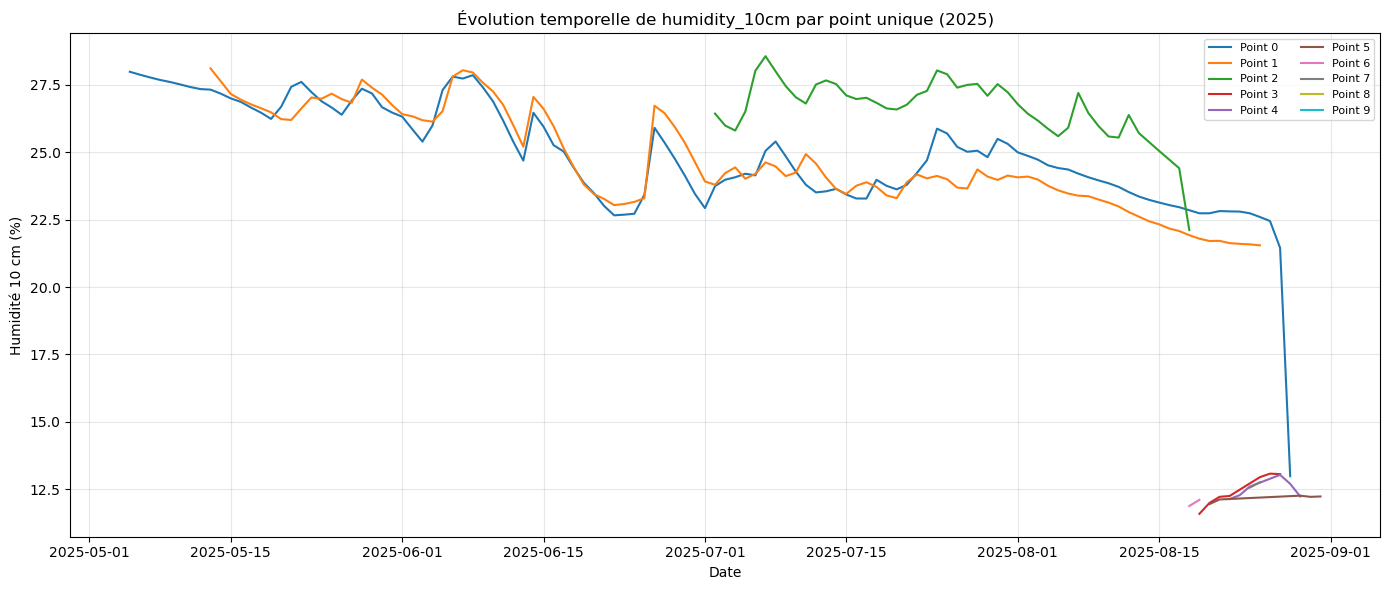

Correspondance numéro de point -> (lat, lon) :
  Point 0: lat=49.4730, lon=2.6204, count=78286
  Point 1: lat=50.0744, lon=2.8129, count=52765
  Point 2: lat=49.4541, lon=2.5872, count=4500
  Point 3: lat=49.5134, lon=3.5256, count=384
  Point 4: lat=50.1628, lon=2.5580, count=384
  Point 5: lat=50.5534, lon=2.7852, count=301
  Point 6: lat=49.6078, lon=2.2896, count=96
  Point 7: lat=50.2821, lon=1.7708, count=96
  Point 8: lat=50.5459, lon=2.8205, count=13
  Point 9: lat=49.6466, lon=2.5675, count=5


In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Chargement des données 2025
evo = pd.read_csv("/home/theodore/Téléchargements/Sondes/probes_2025.csv")
evo["timestamp"] = pd.to_datetime(evo["timestamp"], utc=True)
evo = evo.dropna(subset=["humidity_10cm", "latitude", "longitude"])
evo = evo[(evo["longitude"] != 0) | (evo["latitude"] != 0)]

# Attribuer à chaque ligne son point unique (cluster eps=0.01)
def assign_cluster(row, centers=csv_points):
    best, bd = None, 1e9
    for i, c in enumerate(centers):
        d = ((row["latitude"] - c["lat"]) ** 2 + (row["longitude"] - c["lon"]) ** 2) ** 0.5
        if d < bd:
            best, bd = i, d
    return best

evo["cluster"] = evo.apply(assign_cluster, axis=1)

# Moyenne journalière de humidity_10cm par cluster
evo["date"] = evo["timestamp"].dt.date
daily = evo.groupby(["date", "cluster"])["humidity_10cm"].mean().reset_index()

# Palette : une couleur par point unique (matplotlib 'tab10')
cmap = cm.get_cmap("tab10", max(len(csv_points), 10))

plt.figure(figsize=(14, 6))
handles = []
for cl in sorted(daily["cluster"].unique()):
    sub = daily[daily["cluster"] == cl]
    line, = plt.plot(sub["date"], sub["humidity_10cm"],
                     color=cmap(cl % 10), label=f"Point {cl}")
    handles.append(line)

plt.xlabel("Date")
plt.ylabel("Humidité 10 cm (%)")
plt.title("Évolution temporelle de humidity_10cm par point unique (2025)")
plt.legend(handles=handles, loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# Rappel : correspondance numéro de point -> coordonnées
print("Correspondance numéro de point -> (lat, lon) :")
for i, c in enumerate(csv_points):
    print(f"  Point {i}: lat={c['lat']:.4f}, lon={c['lon']:.4f}, count={c['count']}")

In [14]:
# Étendue temporelle (t_min, t_max) de chaque point unique
evo_range = evo.groupby("cluster")["timestamp"].agg(t_min="min", t_max="max").reset_index()

print("Étendue temporelle de chaque point unique (eps=0.01) :")
for _, r in evo_range.iterrows():
    cl = int(r["cluster"])
    c = csv_points[cl]
    dur = (r["t_max"] - r["t_min"]).days
    print(f"Point {cl:2d} (lat={c['lat']:.4f}, lon={c['lon']:.4f})  "
          f"t_min={r['t_min']}  t_max={r['t_max']}  (durée={dur} j)")


Étendue temporelle de chaque point unique (eps=0.01) :
Point  0 (lat=49.4730, lon=2.6204)  t_min=2025-05-05 11:14:14+00:00  t_max=2025-08-28 07:38:20+00:00  (durée=114 j)
Point  1 (lat=50.0744, lon=2.8129)  t_min=2025-05-13 09:51:08+00:00  t_max=2025-08-25 08:37:11+00:00  (durée=103 j)
Point  2 (lat=49.4541, lon=2.5872)  t_min=2025-07-02 12:34:02+00:00  t_max=2025-08-18 13:17:43+00:00  (durée=47 j)
Point  3 (lat=49.5134, lon=3.5256)  t_min=2025-08-19 13:38:11+00:00  t_max=2025-08-27 18:05:17+00:00  (durée=8 j)
Point  4 (lat=50.1628, lon=2.5580)  t_min=2025-08-22 17:53:22+00:00  t_max=2025-08-29 18:17:31+00:00  (durée=7 j)
Point  5 (lat=50.5534, lon=2.7852)  t_min=2025-08-20 13:43:36+00:00  t_max=2025-08-31 21:44:17+00:00  (durée=11 j)
Point  6 (lat=49.6078, lon=2.2896)  t_min=2025-08-18 13:32:46+00:00  t_max=2025-08-19 13:23:05+00:00  (durée=0 j)
Point  7 (lat=50.2821, lon=1.7708)  t_min=2025-08-24 18:04:10+00:00  t_max=2025-08-25 17:54:29+00:00  (durée=0 j)
Point  8 (lat=50.5459, lon=

---

## ⏱️ Étape 5bis : Évolution temporelle + étendue pour le CSV 2024

Mêmes analyses que pour 2025 mais avec `probes_2024.csv` (points uniques eps=0.01 → `csv_points_2024`).

---

## Humidité par Champ (2025) — 3 plus gros points (0, 1, 2), par sonde

On ne garde que les 3 plus gros points aggrégés de `probes_2025.csv` (indices 0, 1, 2 de `csv_points`, triés par count) et on affiche l'humidité par champ, **une courbe par sonde (`no_serie`)**.

Correspondance points 0-1-2 -> champs :
  Point 0 (count=78286) -> Grandvillers
  Point 1 (count=52765) -> Tarteron
  Point 2 (count=4500) -> Cressonsacq


/tmp/ipykernel_14103/3553324413.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", 12)


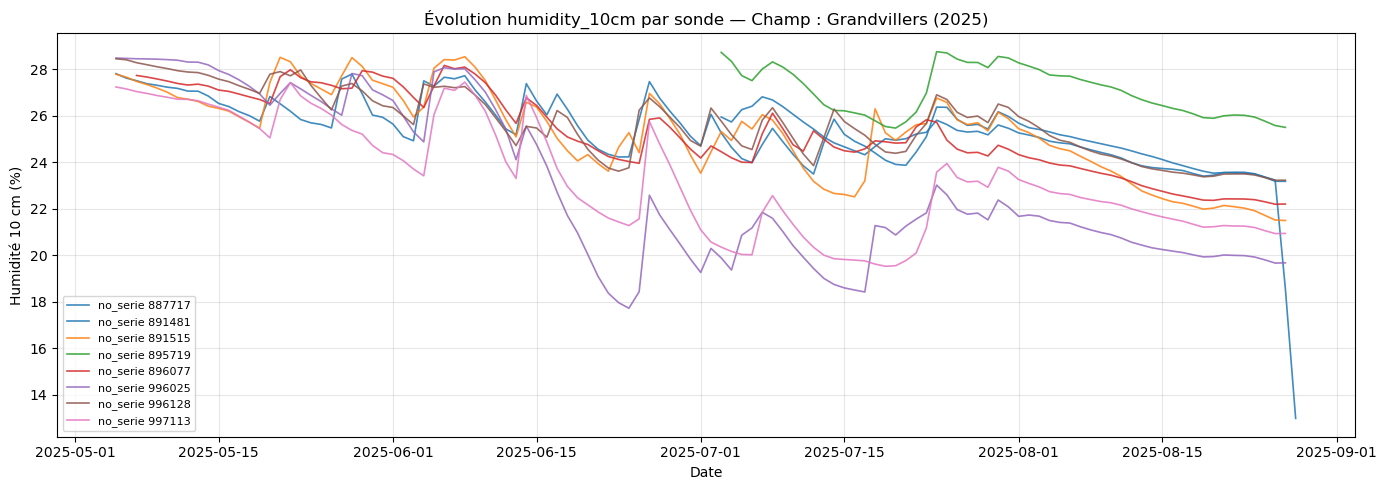

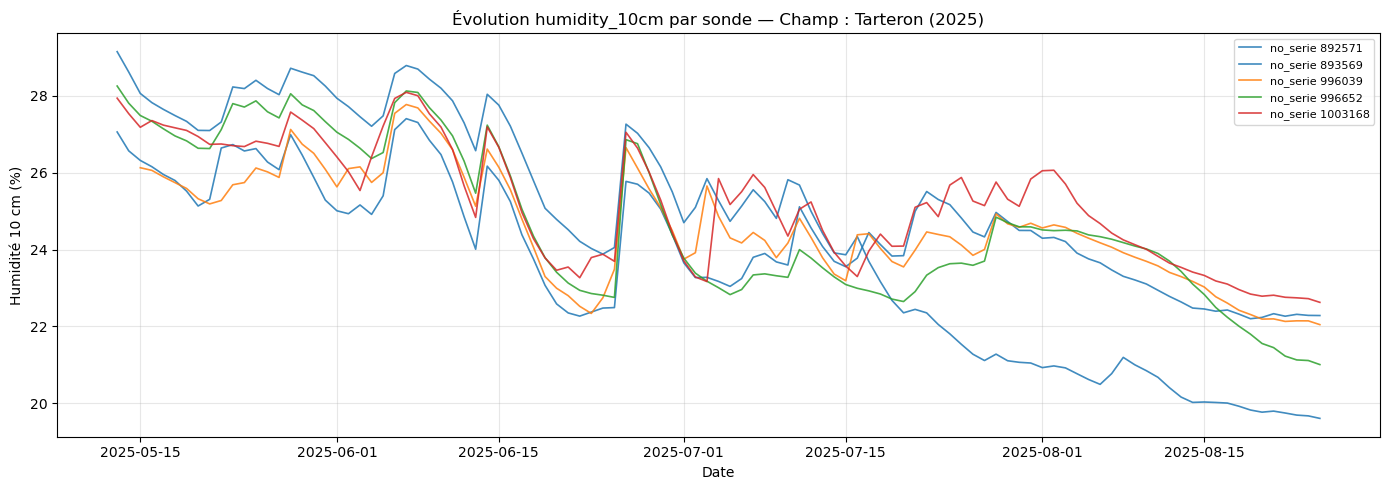

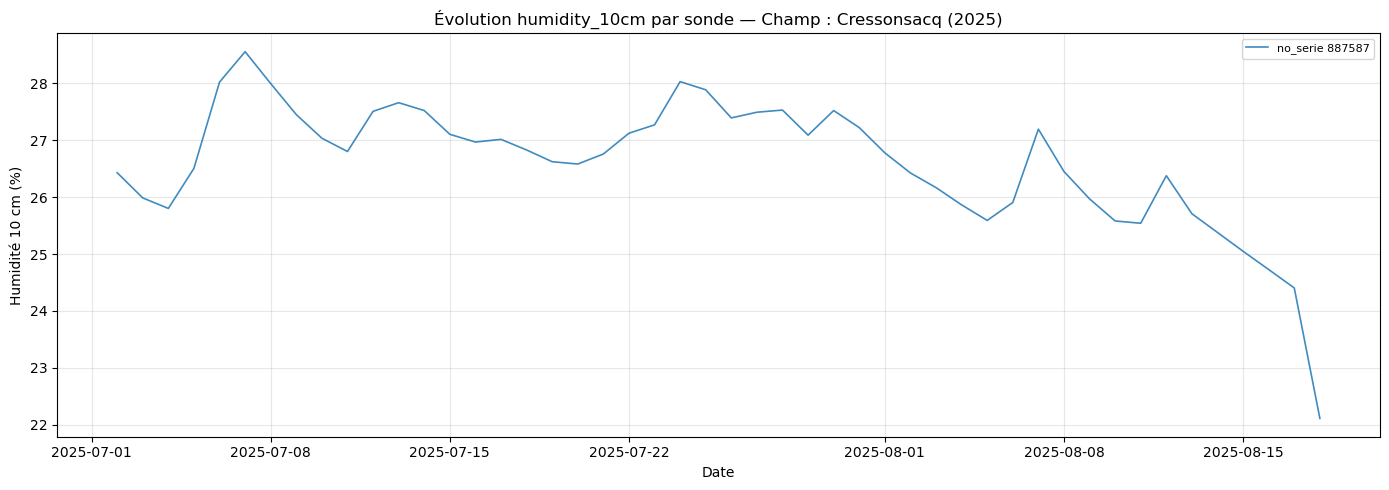


Nombre de mesures par champ / sonde :
field         no_serie
Cressonsacq   887587       4500
Grandvillers  887717       5257
              891481      10743
              891515      10910
              895719       5245
              896077      10706
              996025      10895
              996128      10909
              997113      10895
Tarteron      892571       9938
              893569       9938
              996039       9719
              996652       9938
              1003168      9938


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Les 3 plus gros points (déjà triés par count décroissant dans csv_points)
top3 = csv_points[:3]

# Correspondance champ -> coordonnées représentatives
field_centers = {
    "Grandvillers": (49.4727, 2.6201),
    "Tarteron": (50.0734, 2.8114),
    "Cressonsacq": (49.4547, 2.5870),
}

def nearest_field(lat, lon):
    best, bd = None, 1e9
    for name, (fla, flo) in field_centers.items():
        d = ((lat - fla) ** 2 + (lon - flo) ** 2) ** 0.5
        if d < bd:
            best, bd = name, d
    return best

top3_fields = [nearest_field(p["lat"], p["lon"]) for p in top3]
print("Correspondance points 0-1-2 -> champs :")
for i, (p, f) in enumerate(zip(top3, top3_fields)):
    print(f"  Point {i} (count={p['count']}) -> {f}")

# Chargement des données 2025
evo = pd.read_csv("/home/theodore/Téléchargements/Sondes/probes_2025.csv")
evo["timestamp"] = pd.to_datetime(evo["timestamp"], utc=True)
evo = evo.dropna(subset=["humidity_10cm", "latitude", "longitude"])
evo = evo[(evo["longitude"] != 0) | (evo["latitude"] != 0)]

# Attribuer chaque ligne au plus proche des 3 points retenus (avec seuil max)
MAX_DIST = 0.02

def assign_field(row):
    best, bd = None, 1e9
    for i, c in enumerate(top3):
        d = ((row["latitude"] - c["lat"]) ** 2 + (row["longitude"] - c["lon"]) ** 2) ** 0.5
        if d < bd:
            best, bd = i, d
    return top3_fields[best] if bd <= MAX_DIST else None

evo["field"] = evo.apply(assign_field, axis=1)
evo = evo.dropna(subset=["field"])

# Moyenne journalière de humidity_10cm par (champ, sonde)
evo["date"] = evo["timestamp"].dt.date
daily = evo.groupby(["date", "field", "no_serie"])["humidity_10cm"].mean().reset_index()

# Une figure par champ, une courbe par sonde (no_serie)
cmap = cm.get_cmap("tab10", 12)
for field in field_centers:
    sub = daily[daily["field"] == field]
    plt.figure(figsize=(14, 5))
    ns_list = sorted(sub["no_serie"].unique())
    for j, ns in enumerate(ns_list):
        g = sub[sub["no_serie"] == ns]
        plt.plot(g["date"], g["humidity_10cm"],
                 color=cmap(j % 12), label=f"no_serie {ns}", linewidth=1.2, alpha=0.85)
    plt.xlabel("Date")
    plt.ylabel("Humidité 10 cm (%)")
    plt.title(f"Évolution humidity_10cm par sonde — Champ : {field} (2025)")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

# Récapitulatif mesures par (champ, sonde)
print("\nNombre de mesures par champ / sonde :")
print(evo.groupby(["field", "no_serie"]).size().to_string())

/tmp/ipykernel_14103/78998216.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap24 = cm.get_cmap("tab10", max(len(csv_points_2024), 10))


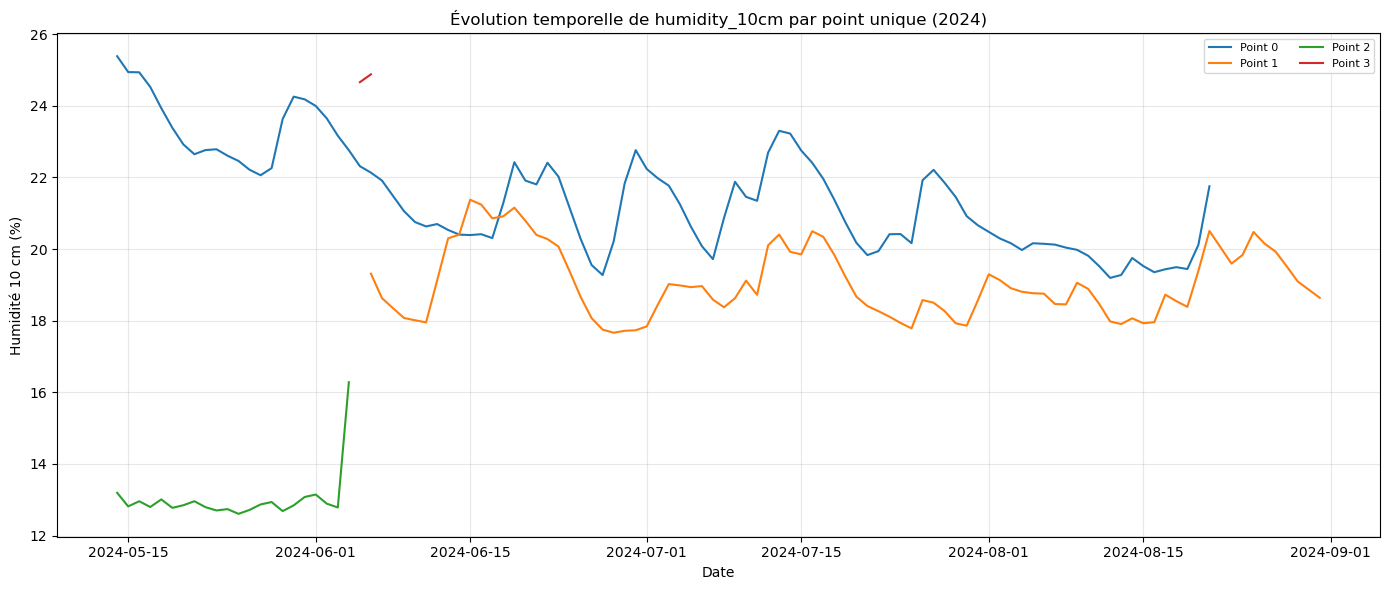

Correspondance numéro de point -> (lat, lon) :
  Point 0: lat=49.5350, lon=2.6801, count=74251
  Point 1: lat=50.0692, lon=2.3376, count=62605
  Point 2: lat=50.5450, lon=2.8183, count=2492
  Point 3: lat=49.5693, lon=2.5639, count=104


In [27]:
# --- Évolution temporelle humidity_10cm par point unique (2024) ---
evo24 = pd.read_csv("/home/theodore/Téléchargements/Sondes/probes_2024.csv")
evo24["timestamp"] = pd.to_datetime(evo24["timestamp"], utc=True)
evo24 = evo24.dropna(subset=["humidity_10cm", "latitude", "longitude"])
evo24 = evo24[(evo24["longitude"] != 0) | (evo24["latitude"] != 0)]

def assign_cluster24(row, centers=csv_points_2024):
    best, bd = None, 1e9
    for i, c in enumerate(centers):
        d = ((row["latitude"] - c["lat"]) ** 2 + (row["longitude"] - c["lon"]) ** 2) ** 0.5
        if d < bd:
            best, bd = i, d
    return best

evo24["cluster"] = evo24.apply(assign_cluster24, axis=1)
evo24["date"] = evo24["timestamp"].dt.date
daily24 = evo24.groupby(["date", "cluster"])["humidity_10cm"].mean().reset_index()

cmap24 = cm.get_cmap("tab10", max(len(csv_points_2024), 10))

plt.figure(figsize=(14, 6))
handles24 = []
for cl in sorted(daily24["cluster"].unique()):
    sub = daily24[daily24["cluster"] == cl]
    line, = plt.plot(sub["date"], sub["humidity_10cm"],
                     color=cmap24(cl % 10), label=f"Point {cl}")
    handles24.append(line)

plt.xlabel("Date")
plt.ylabel("Humidité 10 cm (%)")
plt.title("Évolution temporelle de humidity_10cm par point unique (2024)")
plt.legend(handles=handles24, loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

print("Correspondance numéro de point -> (lat, lon) :")
for i, c in enumerate(csv_points_2024):
    print(f"  Point {i}: lat={c['lat']:.4f}, lon={c['lon']:.4f}, count={c['count']}")

In [28]:
# --- Étendue temporelle (t_min, t_max) de chaque point unique (2024) ---
evo_range24 = evo24.groupby("cluster")["timestamp"].agg(t_min="min", t_max="max").reset_index()

print("Étendue temporelle de chaque point unique 2024 (eps=0.01) :")
for _, r in evo_range24.iterrows():
    cl = int(r["cluster"])
    c = csv_points_2024[cl]
    dur = (r["t_max"] - r["t_min"]).days
    print(f"Point {cl:2d} (lat={c['lat']:.4f}, lon={c['lon']:.4f})  "
          f"t_min={r['t_min']}  t_max={r['t_max']}  (durée={dur} j)")


Étendue temporelle de chaque point unique 2024 (eps=0.01) :
Point  0 (lat=49.5350, lon=2.6801)  t_min=2024-05-14 15:43:06+00:00  t_max=2024-08-21 14:43:57+00:00  (durée=98 j)
Point  1 (lat=50.0692, lon=2.3376)  t_min=2024-06-06 13:17:40+00:00  t_max=2024-08-31 23:25:34+00:00  (durée=86 j)
Point  2 (lat=50.5450, lon=2.8183)  t_min=2024-05-14 14:33:44+00:00  t_max=2024-06-04 12:35:14+00:00  (durée=20 j)
Point  3 (lat=49.5693, lon=2.5639)  t_min=2024-06-05 10:04:16+00:00  t_max=2024-06-06 09:54:32+00:00  (durée=0 j)


Correspondance points 0-1-2 -> champs :
  Point 0 (count=74251) -> 1
  Point 1 (count=62605) -> 2


/tmp/ipykernel_14103/1795569906.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", 12)


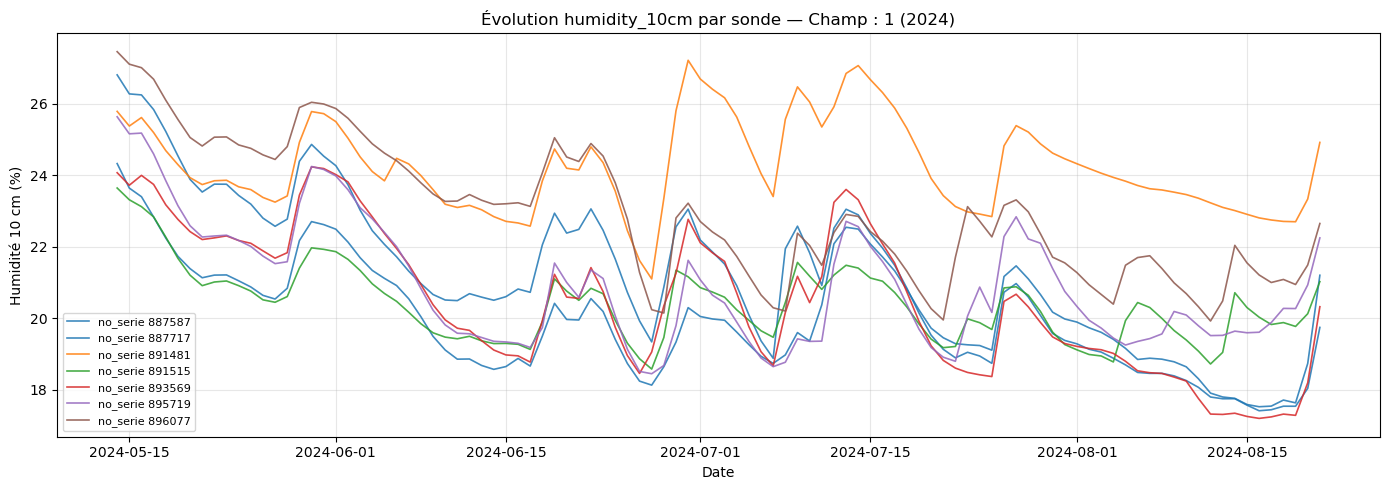

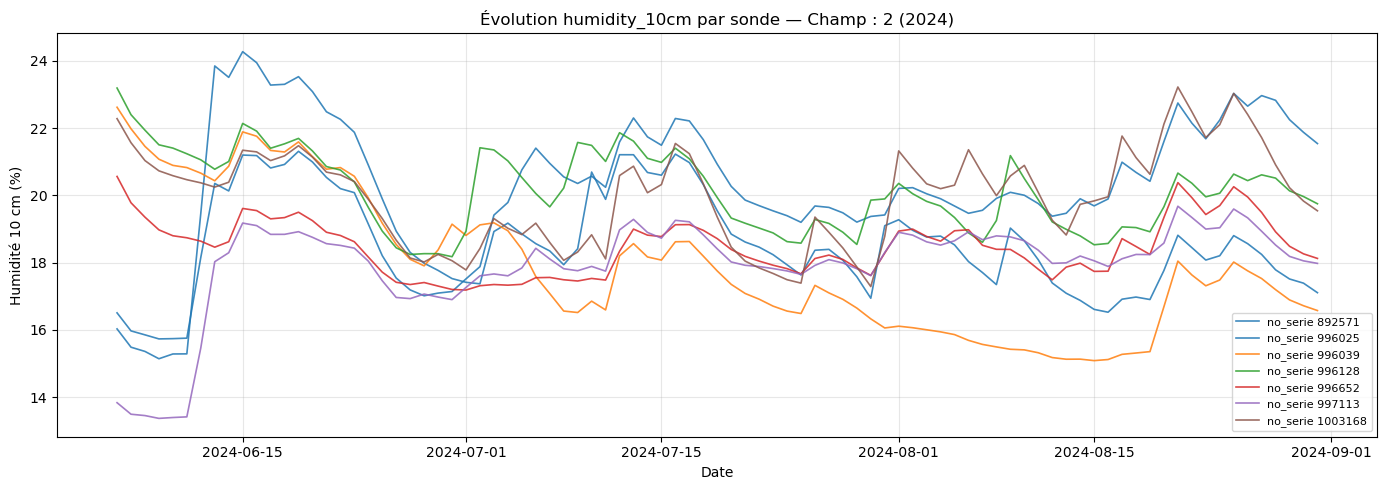


Nombre de mesures par champ / sonde :
field  no_serie
1      887587      9764
       887717      9750
       891481      9659
       891515      9772
       893569      9770
       895719      9779
       896077      9797
2      892571      8275
       996025      8252
       996039      8266
       996128      8258
       996652      8268
       997113      8244
       1003168     8231


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Les 3 plus gros points (déjà triés par count décroissant dans csv_points)
top3 = csv_points_2024[:2]

# Correspondance champ -> coordonnées représentatives
field_centers = {
    "1": (49.5350, 2.6801),
    "2": (50.0692, 2.3376),
}

def nearest_field(lat, lon):
    best, bd = None, 1e9
    for name, (fla, flo) in field_centers.items():
        d = ((lat - fla) ** 2 + (lon - flo) ** 2) ** 0.5
        if d < bd:
            best, bd = name, d
    return best

top3_fields = [nearest_field(p["lat"], p["lon"]) for p in top3]
print("Correspondance points 0-1-2 -> champs :")
for i, (p, f) in enumerate(zip(top3, top3_fields)):
    print(f"  Point {i} (count={p['count']}) -> {f}")


# Chargement des données 2024
evo = pd.read_csv("/home/theodore/Téléchargements/Sondes/probes_2024.csv")
evo["timestamp"] = pd.to_datetime(evo["timestamp"], utc=True)
evo = evo.dropna(subset=["humidity_10cm", "latitude", "longitude"])
evo = evo[(evo["longitude"] != 0) | (evo["latitude"] != 0)]

# Attribuer chaque ligne au plus proche des 3 points retenus (avec seuil max)
MAX_DIST = 0.02

def assign_field(row):
    best, bd = None, 1e9
    for i, c in enumerate(top3):
        d = ((row["latitude"] - c["lat"]) ** 2 + (row["longitude"] - c["lon"]) ** 2) ** 0.5
        if d < bd:
            best, bd = i, d
    return top3_fields[best] if bd <= MAX_DIST else None

evo["field"] = evo.apply(assign_field, axis=1)
evo = evo.dropna(subset=["field"])

# Moyenne journalière de humidity_10cm par (champ, sonde)
evo["date"] = evo["timestamp"].dt.date
daily = evo.groupby(["date", "field", "no_serie"])["humidity_10cm"].mean().reset_index()

# Une figure par champ, une courbe par sonde (no_serie)
cmap = cm.get_cmap("tab10", 12)
for field in field_centers:
    sub = daily[daily["field"] == field]
    plt.figure(figsize=(14, 5))
    ns_list = sorted(sub["no_serie"].unique())
    for j, ns in enumerate(ns_list):
        g = sub[sub["no_serie"] == ns]
        plt.plot(g["date"], g["humidity_10cm"],
                 color=cmap(j % 12), label=f"no_serie {ns}", linewidth=1.2, alpha=0.85)
    plt.xlabel("Date")
    plt.ylabel("Humidité 10 cm (%)")
    plt.title(f"Évolution humidity_10cm par sonde — Champ : {field} (2024)")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

# Récapitulatif mesures par (champ, sonde)
print("\nNombre de mesures par champ / sonde :")
print(evo.groupby(["field", "no_serie"]).size().to_string())

---

## 📈 Étape 7 : Relire et afficher les courbes depuis `Osiris_2025`

Parcourt le dossier `Osiris_2025`, affiche chaque courbe et imprime le champ et le nom du fichier.

Champ=Cressonsacq | fichier=/home/theodore/Téléchargements/Osiris_2025/Cressonsacq/Canon.csv | lignes=1116


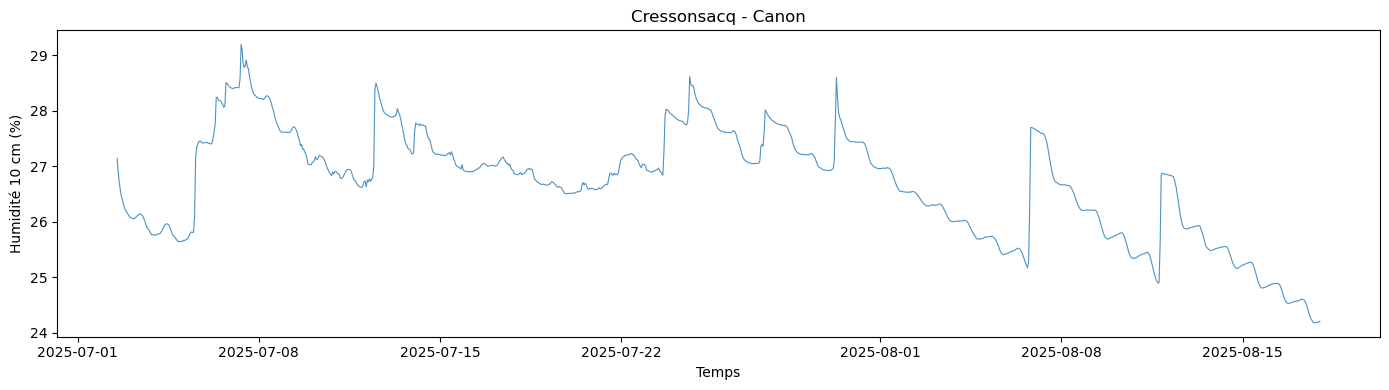

Champ=Cressonsacq | fichier=/home/theodore/Téléchargements/Osiris_2025/Cressonsacq/Robot.csv | lignes=1131


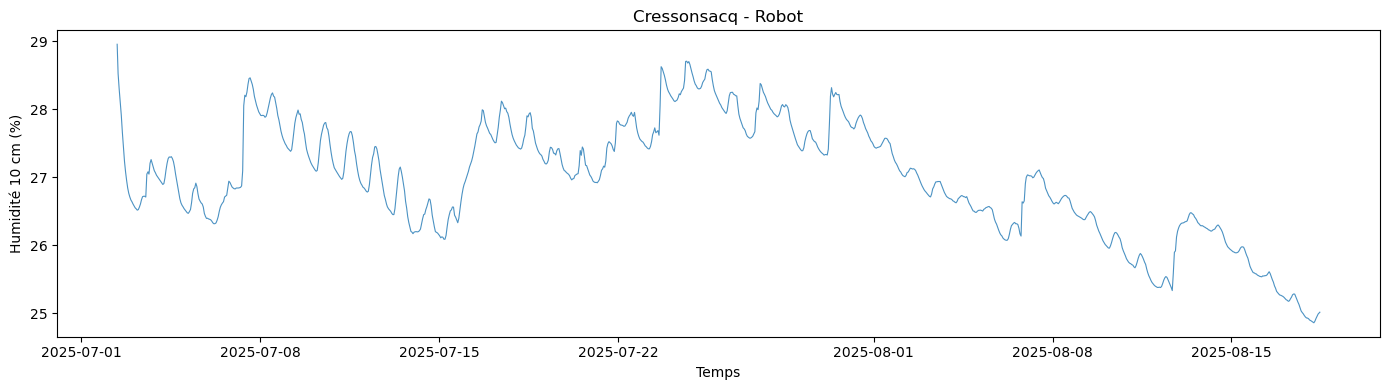

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Canon 1.csv | lignes=2668


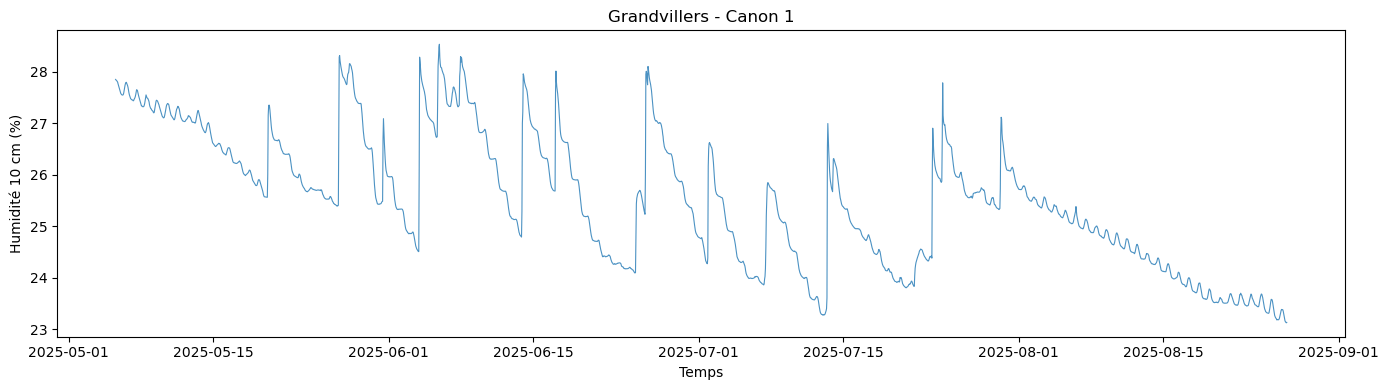

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Canon 2.csv | lignes=2737


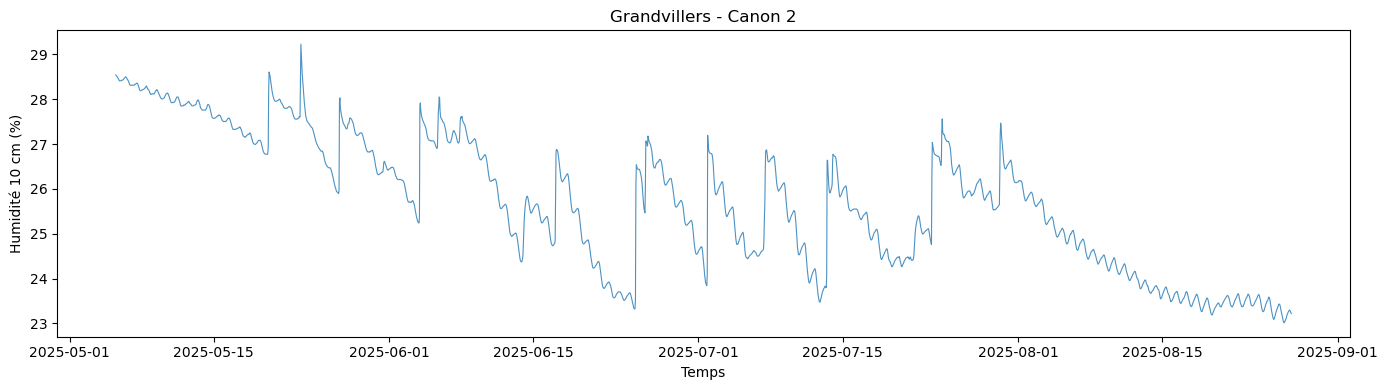

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Canon 3.csv | lignes=2738


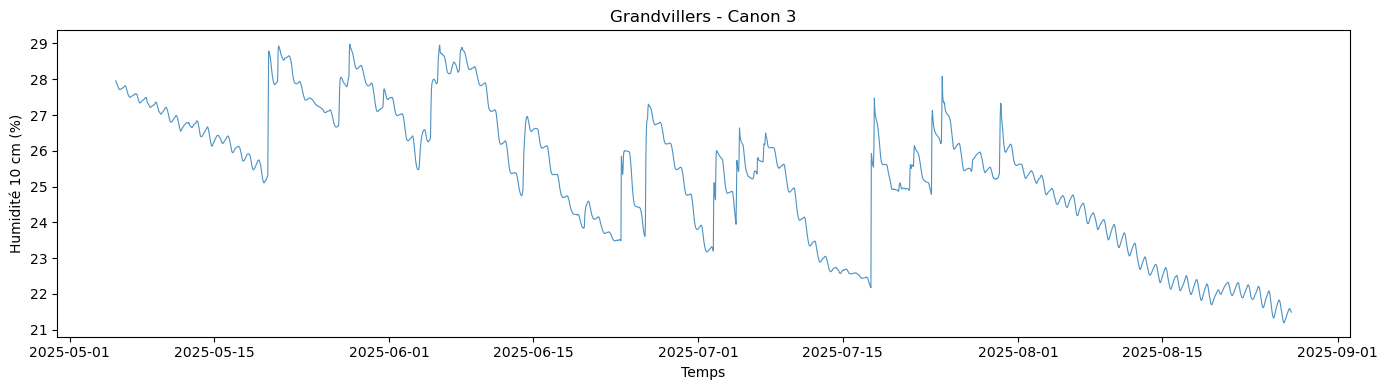

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Robot -20 2.csv | lignes=1344


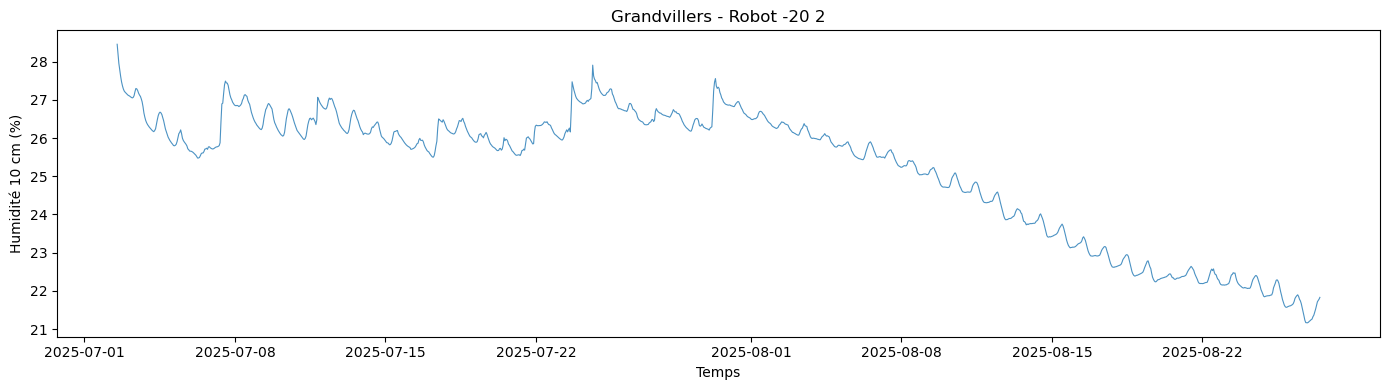

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Robot -20.csv | lignes=2686


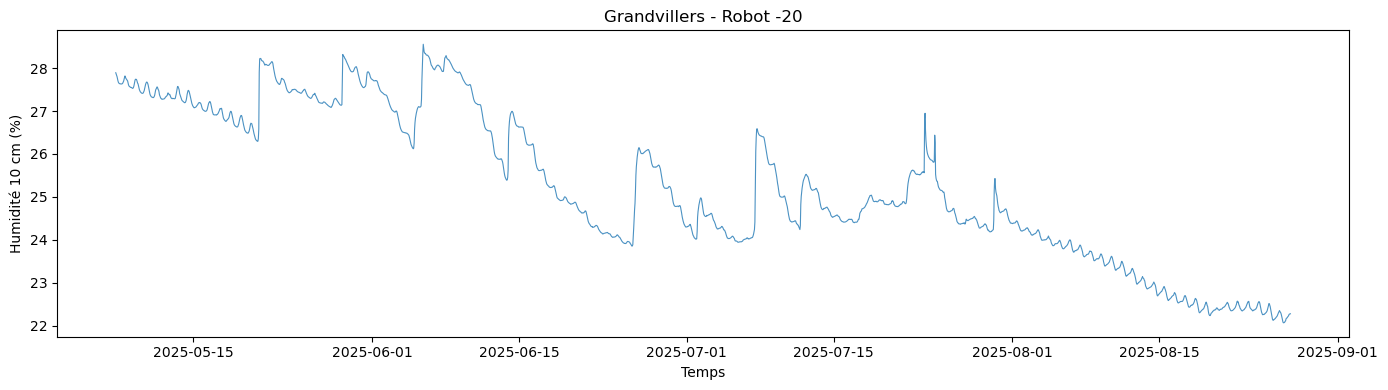

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Robot 2.csv | lignes=1319


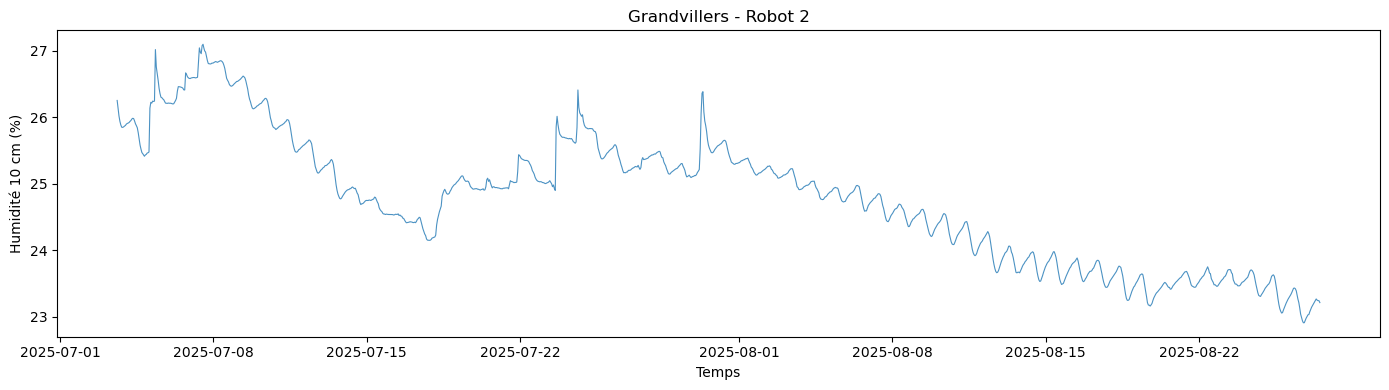

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Robot.csv | lignes=2735


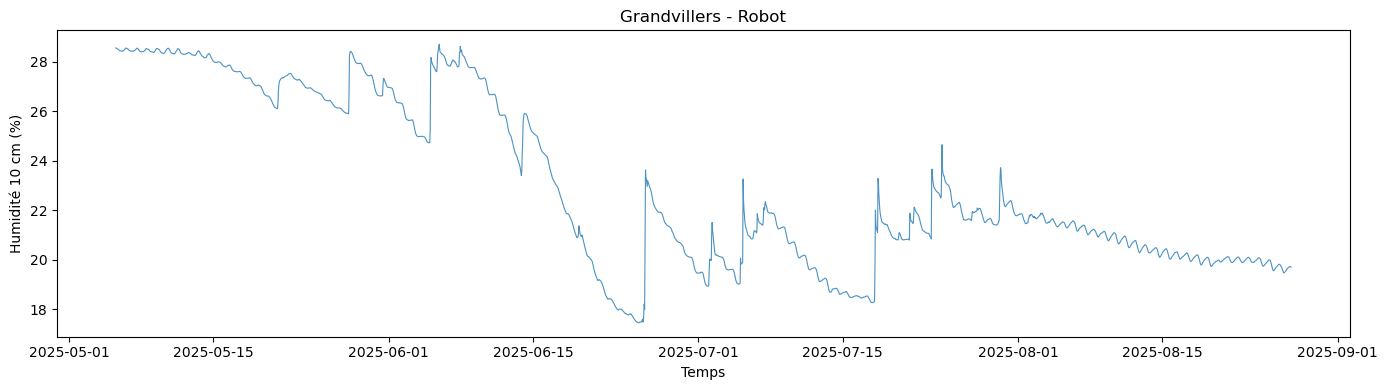

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Sec 2.csv | lignes=1317


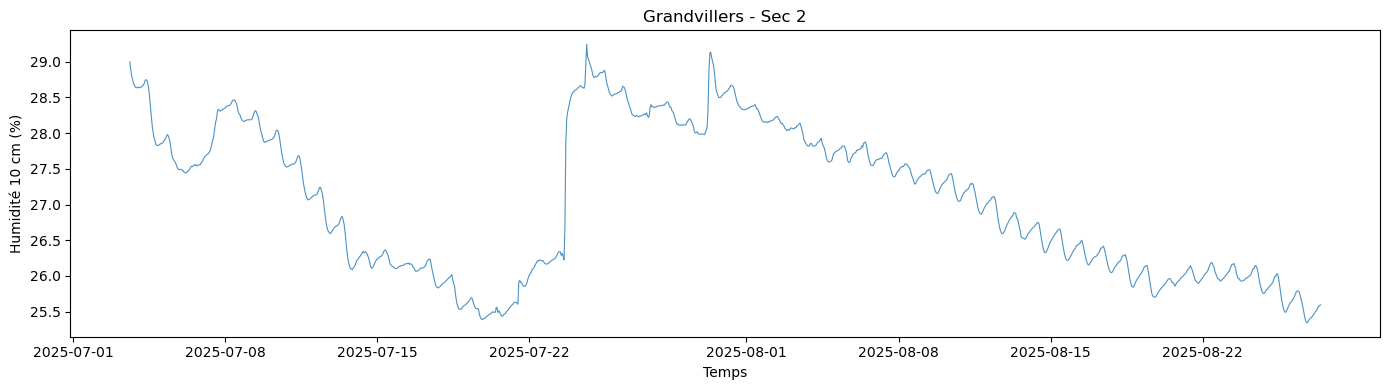

Champ=Grandvillers | fichier=/home/theodore/Téléchargements/Osiris_2025/Grandvillers/Sec.csv | lignes=2735


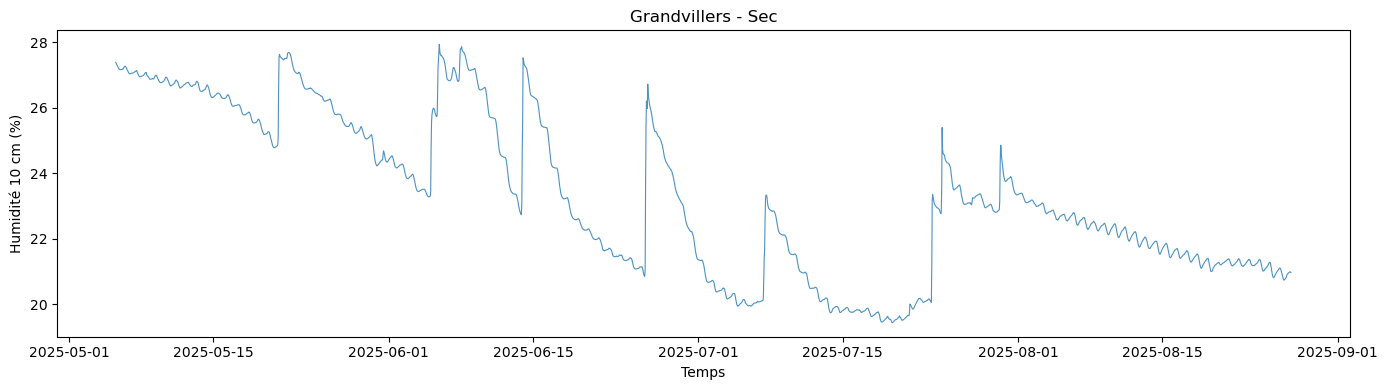

Champ=Tarteron | fichier=/home/theodore/Téléchargements/Osiris_2025/Tarteron/Robot -15.csv | lignes=2440


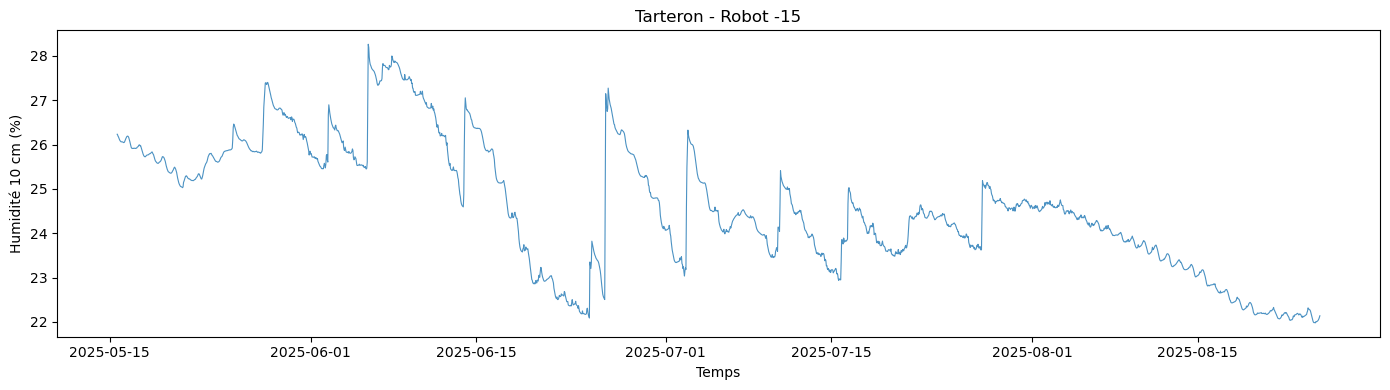

Champ=Tarteron | fichier=/home/theodore/Téléchargements/Osiris_2025/Tarteron/Robot -30.csv | lignes=2455


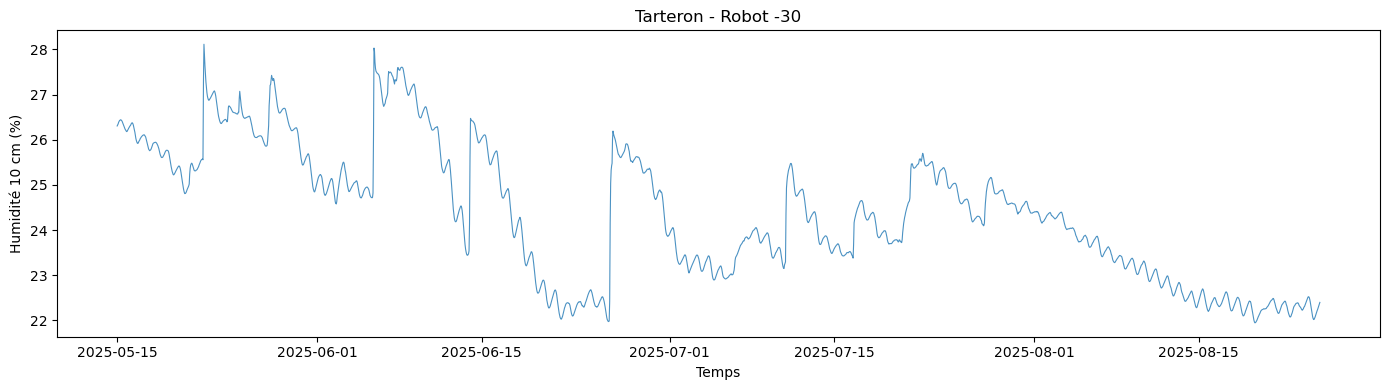

Champ=Tarteron | fichier=/home/theodore/Téléchargements/Osiris_2025/Tarteron/Robot N.csv | lignes=2456


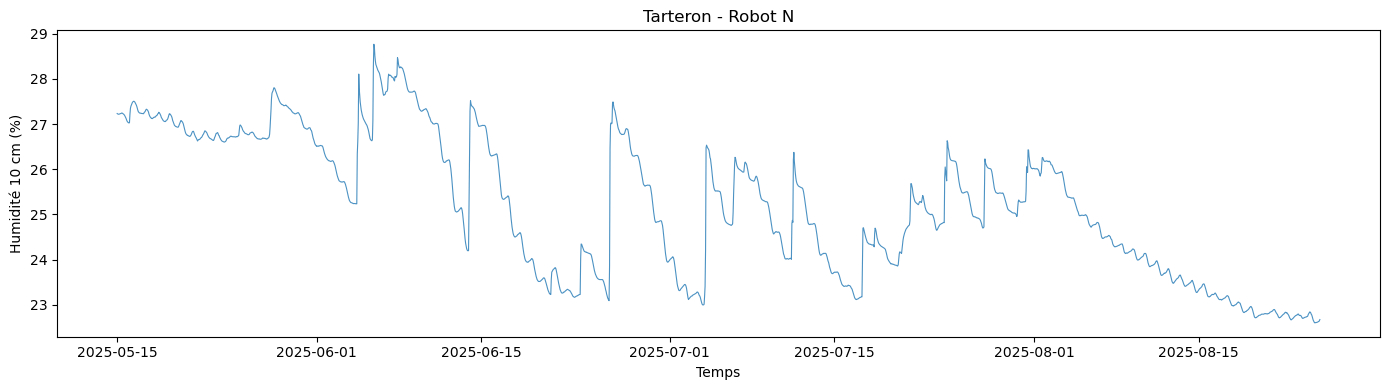

Champ=Tarteron | fichier=/home/theodore/Téléchargements/Osiris_2025/Tarteron/Robot.csv | lignes=2452


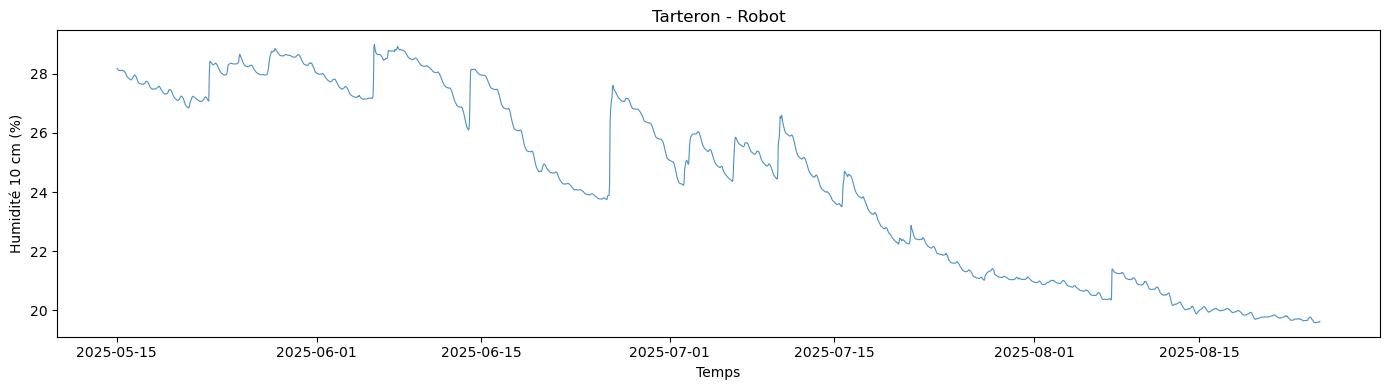

Champ=Tarteron | fichier=/home/theodore/Téléchargements/Osiris_2025/Tarteron/Sec.csv | lignes=2455


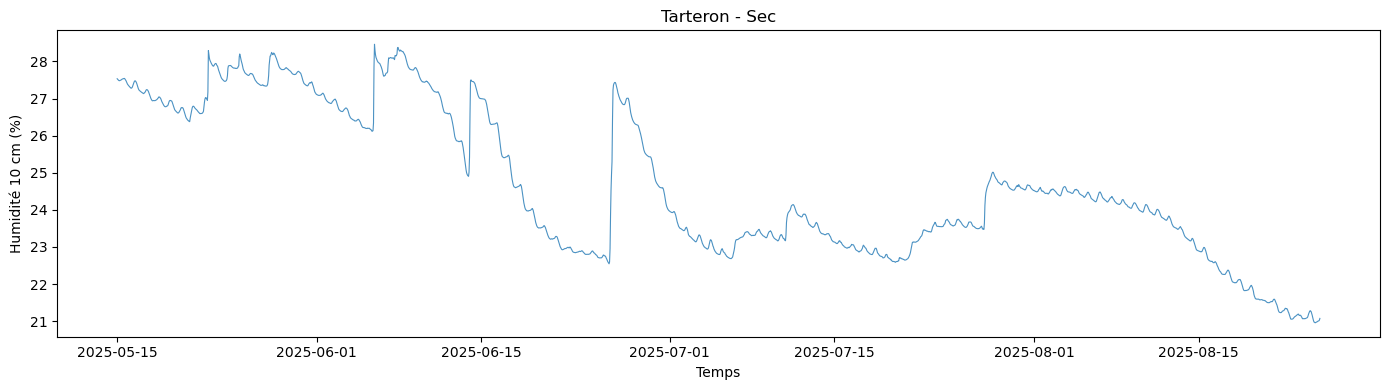

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

_base = "/home/theodore/Téléchargements/Osiris_2025"

for _field in sorted(os.listdir(_base)):
    _fdir = os.path.join(_base, _field)
    if not os.path.isdir(_fdir):
        continue
    for _fname in sorted(os.listdir(_fdir)):
        if not _fname.endswith(".csv"):
            continue
        _path = os.path.join(_fdir, _fname)
        _df = pd.read_csv(_path)
        _df["timestamp"] = pd.to_datetime(_df["timestamp"], format="mixed")
        _df = _df.sort_values("timestamp")
        _name = os.path.splitext(_fname)[0]

        print(f"Champ={_field} | fichier={_path} | lignes={len(_df)}")
        plt.figure(figsize=(14, 4))
        plt.plot(_df["timestamp"], _df["humidity_10cm"], linewidth=0.8, alpha=0.8)
        plt.xlabel("Temps")
        plt.ylabel("Humidité 10 cm (%)")
        plt.title(f"{_field} - {_name}")
        plt.tight_layout()
        plt.show()

# Osiris 2026 — Carte des sondes + Évolution humidity_10cm

Dump `osiris_2026.csv` (15 sondes). Les sondes 2026 = **mêmes numéros de série qu'en 2025
mais déployées sur de nouveaux champs** (coordonnées ≠ champs 2024/2025). Regroupement par
champ (seuil ε = 0.02°), carte folium, puis moyenne journalière humidity_10cm par champ.

> Sonde **115260** : aucun couple lat/lon → exclue des champs et de la carte (traitée en fin).

In [1]:
# ---------- Osiris 2026 : chargement + regroupement en champs ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import folium
from IPython.display import display

CSV_2026 = "/home/theodore/Documents/Get_Datasets/Osiris_data/osiris_2026.csv"
EPS = 0.02

df26 = pd.read_csv(CSV_2026)
df26["timestamp"] = pd.to_datetime(df26["ts"], utc=True)
df26["no_serie"] = df26["probe_serial_number"]
df26["humidity_10cm"] = df26["humidity_10cm_value"]

print(f"lignes totales : {len(df26)} | sondes : {df26['no_serie'].nunique()} | "
      f"{df26['timestamp'].min():%Y-%m-%d} → {df26['timestamp'].max():%Y-%m-%d}")

probes26 = []
for s, g in df26.groupby("no_serie"):
    lat = g["latitude"].dropna().mean()
    lon = g["longitude"].dropna().mean()
    probes26.append({"no_serie": s, "lat": lat, "lon": lon, "count": len(g),
                     "tmin": g["timestamp"].min(), "tmax": g["timestamp"].max()})
probes26.sort(key=lambda x: -x["count"])

clusters26, assignments26 = [], {}
for pr in probes26:
    if not np.isfinite(pr["lat"]) or not np.isfinite(pr["lon"]):
        assignments26[pr["no_serie"]] = None
        continue
    matched = None
    for c in clusters26:
        if ((pr["lat"] - c["lat"]) ** 2 + (pr["lon"] - c["lon"]) ** 2) ** 0.5 <= EPS:
            matched = c
            break
    if matched is None:
        matched = {"lat": pr["lat"], "lon": pr["lon"], "members": []}
        clusters26.append(matched)
    matched["members"].append(pr["no_serie"])
    assignments26[pr["no_serie"]] = clusters26.index(matched)

order = sorted(range(len(clusters26)), key=lambda i: -clusters26[i]["lat"])
label26 = {i: f"Champ {chr(65 + j)}" for j, i in enumerate(order)}

print(f"{'champ':>10} {'lat':>10} {'lon':>10} {'sondes':>24} {'lignes':>7}  période")
for i in sorted(range(len(clusters26)), key=lambda k: label26[k]):
    c = clusters26[i]
    lignes = sum(pr["count"] for pr in probes26 if pr["no_serie"] in c["members"])
    tmin = min(pr["tmin"] for pr in probes26 if pr["no_serie"] in c["members"])
    tmax = max(pr["tmax"] for pr in probes26 if pr["no_serie"] in c["members"])
    print(f"{label26[i]:>10} {c['lat']:.5f} {c['lon']:.5f} {str(c['members']):>24} {lignes:>7}  {tmin:%Y-%m-%d} → {tmax:%Y-%m-%d}")

df26["field"] = df26["no_serie"].map(assignments26).map(label26)
print("\nlignes affectées à un champ :", df26["field"].notna().sum(), "/", len(df26))

lignes totales : 135109 | sondes : 15 | 2026-04-28 → 2026-09-09
     champ        lat        lon                   sondes  lignes  période
   Champ A 50.52793 2.78363         [887717, 891481]   24209  2026-05-05 → 2026-09-09
   Champ B 50.36857 1.72880 [1003168, 996652, 996039, 893569]   42374  2026-05-05 → 2026-08-25
   Champ C 49.59812 2.51574         [891515, 996128]   17903  2026-05-23 → 2026-08-24
   Champ D 49.45126 2.65594         [896077, 997113]   18850  2026-04-28 → 2026-08-04
   Champ E 49.43589 2.67567                 [996025]    3991  2026-06-24 → 2026-08-08
   Champ F 49.26498 1.45605                 [895719]    6898  2026-05-23 → 2026-08-03
   Champ G 48.55376 3.87077                 [887587]    8763  2026-05-23 → 2026-08-22
   Champ H 48.32924 2.19956                 [892571]    9408  2026-05-25 → 2026-08-31

lignes affectées à un champ : 132396 / 135109


In [2]:
# ---------- Osiris 2026 : carte folium, 1 marqueur par sonde ----------
cmap26 = colormaps["tab10"].resampled(max(len(clusters26), 10))
fc26 = [folium.FeatureGroup(name=label26[i]) for i in range(len(clusters26))]
for pr in probes26:
    i = assignments26[pr["no_serie"]]
    if i is None:
        continue
    r, g, b = (np.array(cmap26(i % 10)[:3]) * 255).astype(int)
    popup = (f"<b>{pr['no_serie']}</b><br>{label26[i]}<br>"
             f"count = {pr['count']}<br>{pr['tmin']:%Y-%m-%d} → {pr['tmax']:%Y-%m-%d}")
    folium.CircleMarker(
        location=[pr["lat"], pr["lon"]],
        radius=6 + (pr["count"] ** 0.5) * 0.02,
        color=f"#{r:02x}{g:02x}{b:02x}", fill=True,
        fill_color=f"#{r:02x}{g:02x}{b:02x}", fill_opacity=0.85,
        popup=popup,
    ).add_to(fc26[i])

m26 = folium.Map(location=[49.45, 2.6], zoom_start=9)
for f in fc26:
    f.add_to(m26)
folium.LayerControl().add_to(m26)
m26.save("carte_points_2026.html")
display(m26)
print("Carte sauvegardée : carte_points_2026.html")

Carte sauvegardée : carte_points_2026.html


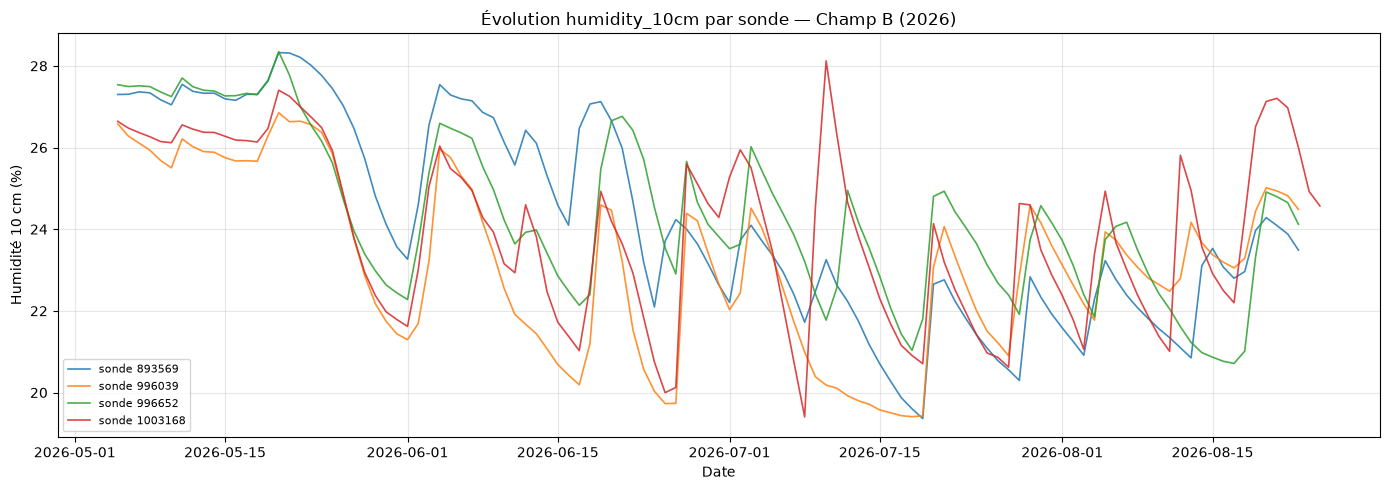

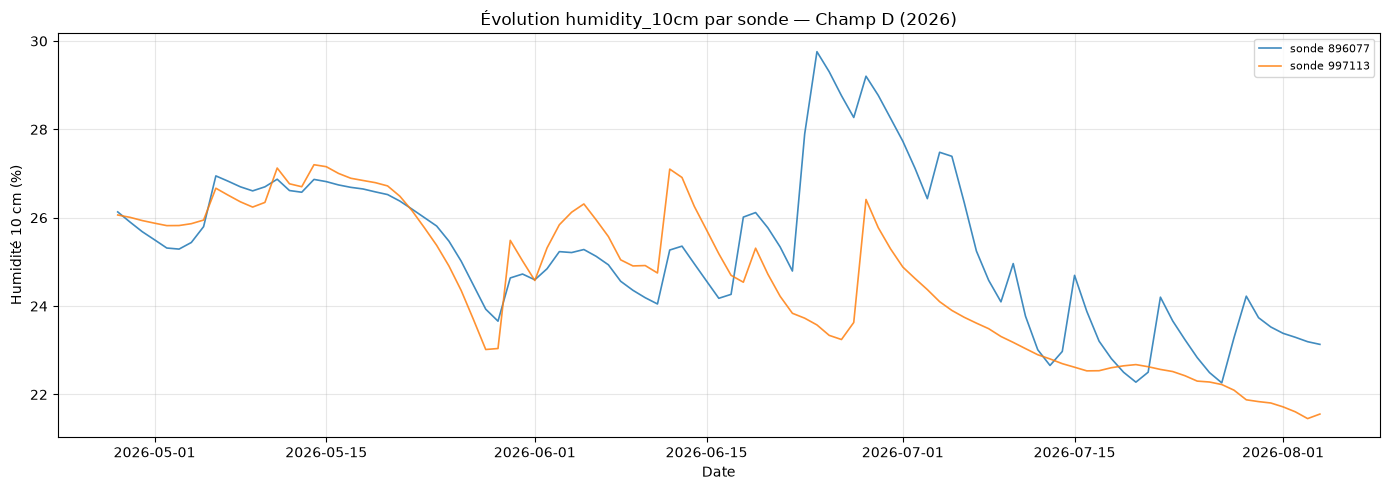

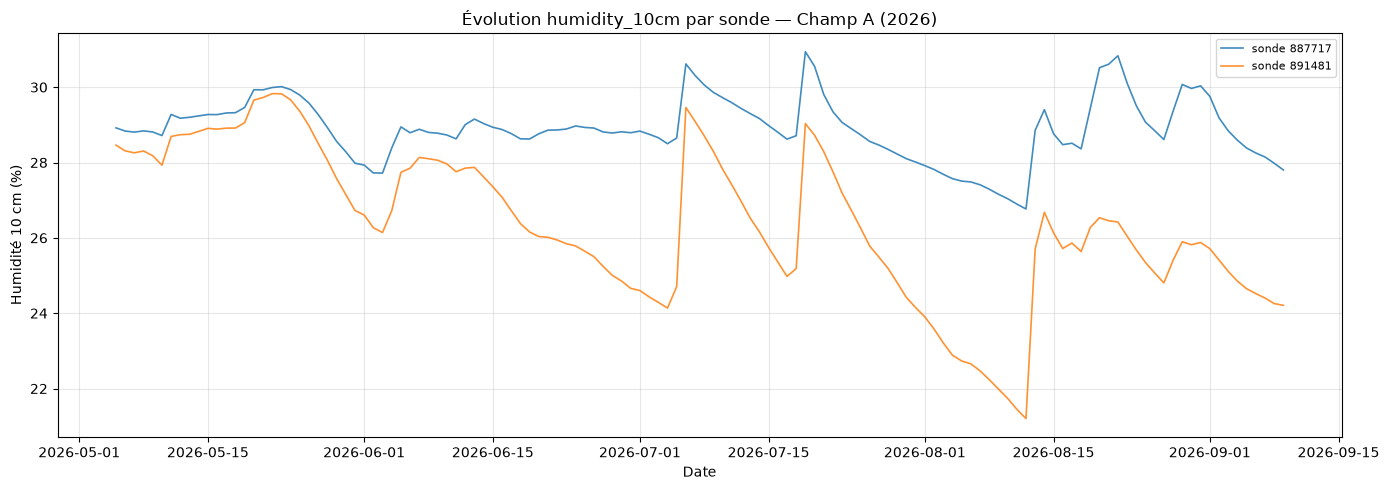

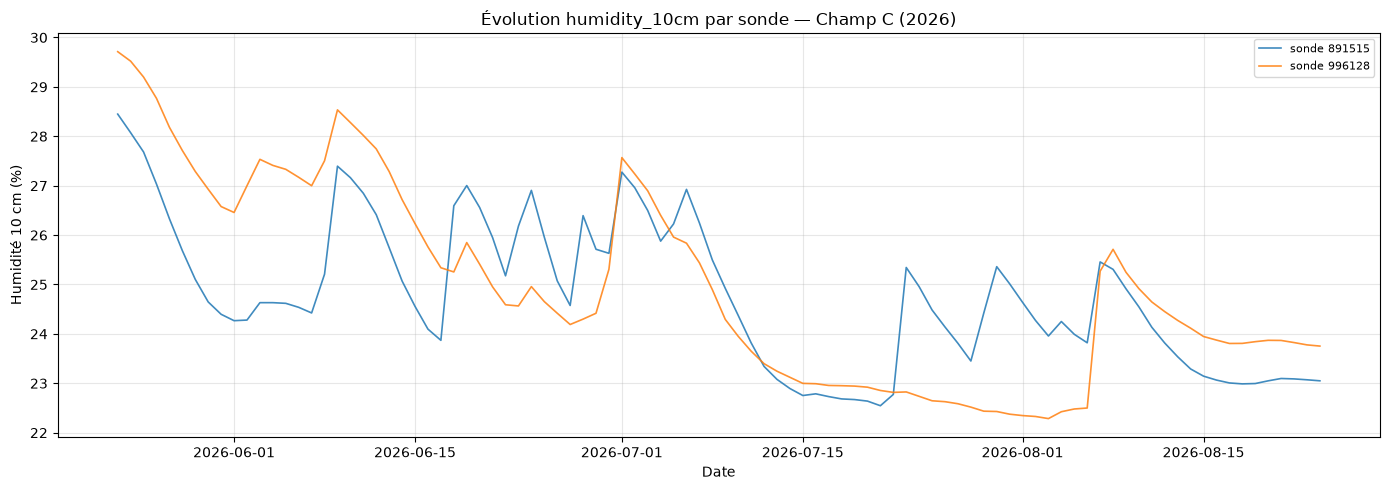

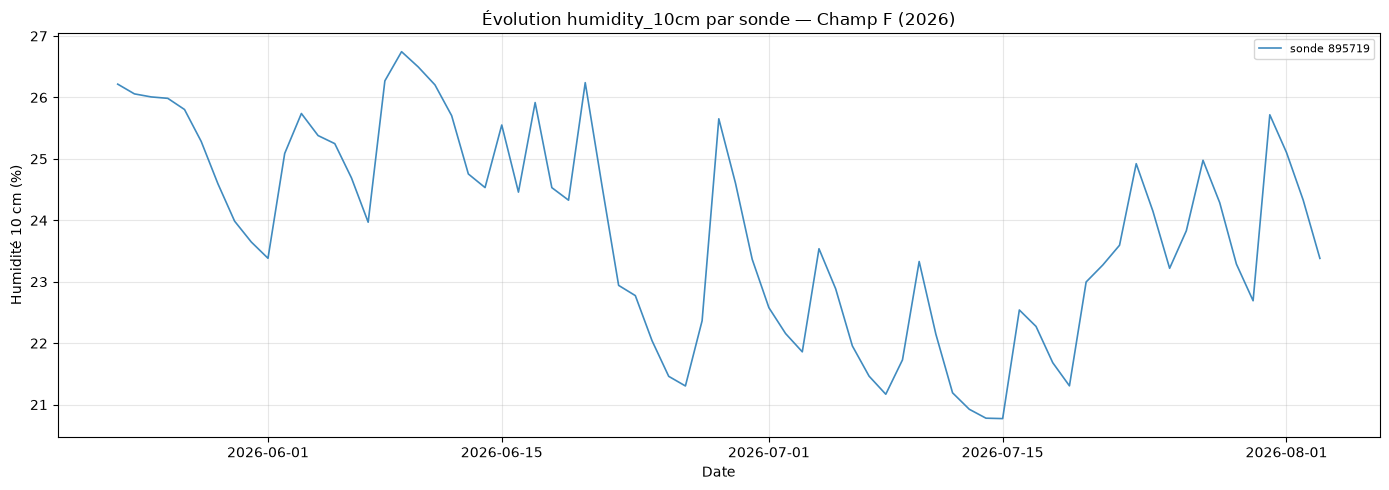

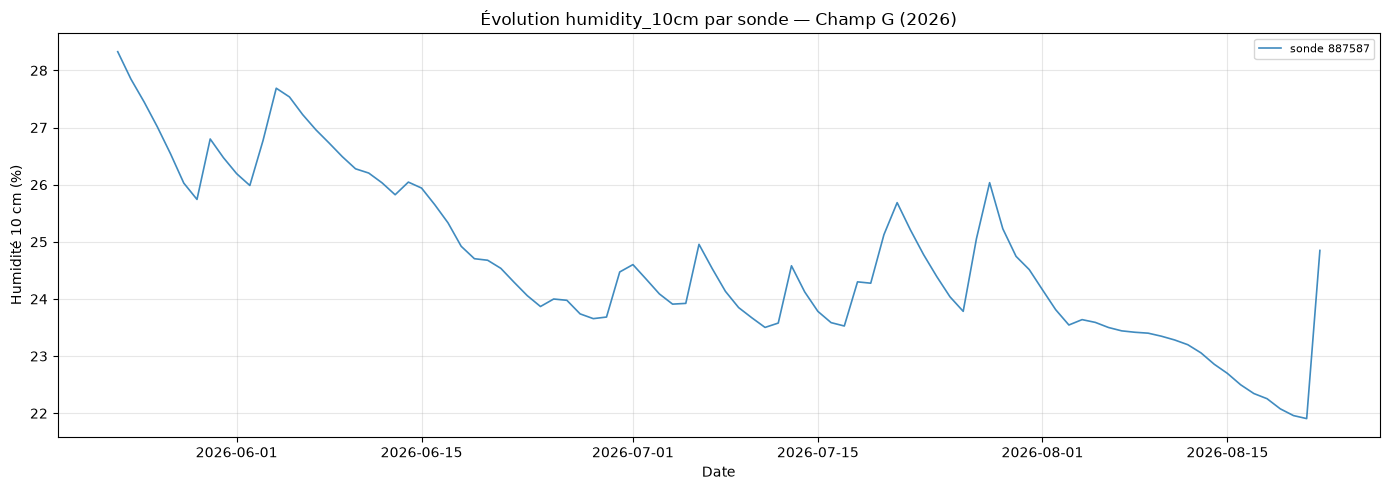

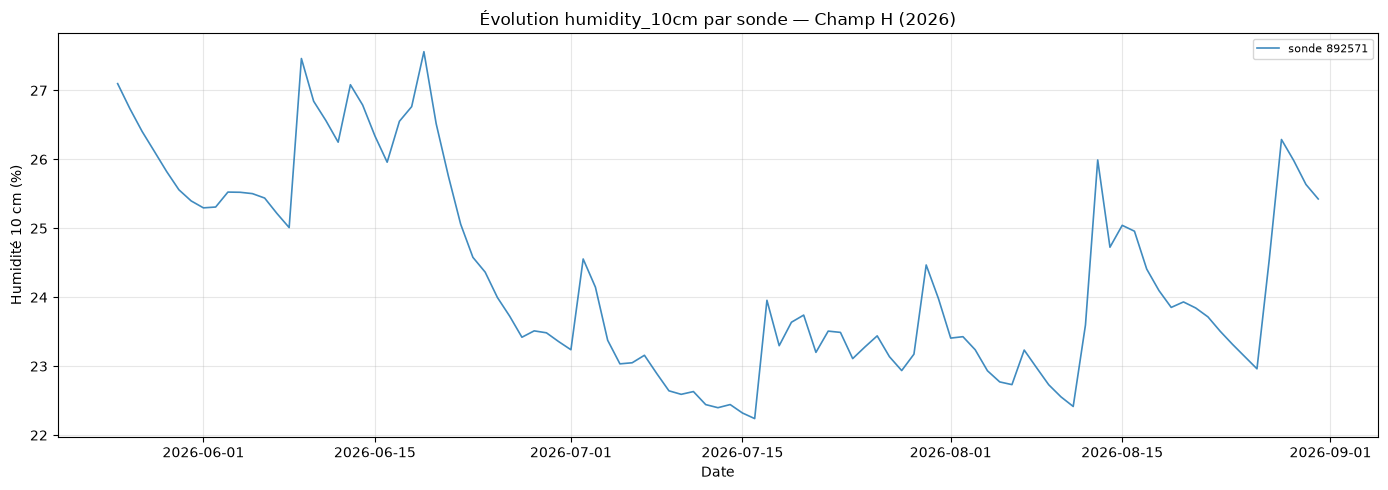

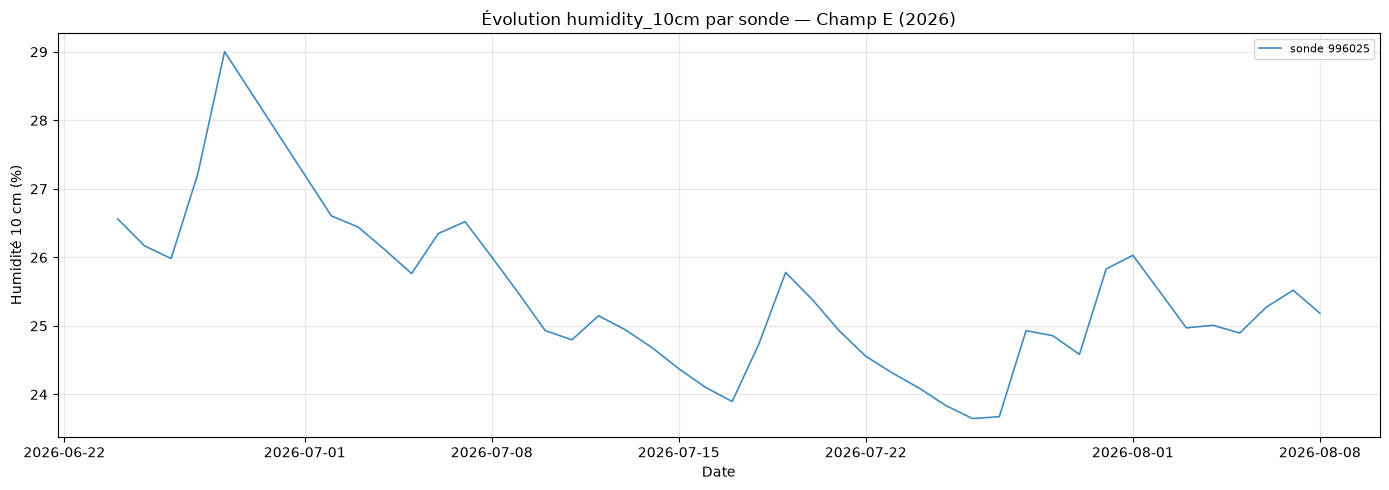

In [3]:
# ---------- Osiris 2026 : humidity_10cm moyenne journalière par (champ, sonde) ----------
sub26 = df26.dropna(subset=["field", "latitude", "longitude", "humidity_10cm"])
sub26 = sub26[(sub26["longitude"] != 0) | (sub26["latitude"] != 0)]
sub26["date"] = sub26["timestamp"].dt.date
daily26 = sub26.groupby(["date", "field", "no_serie"])["humidity_10cm"].mean().reset_index()

for field in sorted(daily26["field"].unique(),
                    key=lambda f: -daily26[daily26["field"] == f]["no_serie"].nunique()):
    fdf = daily26[daily26["field"] == field]
    plt.figure(figsize=(14, 5))
    for j, ns in enumerate(sorted(fdf["no_serie"].unique())):
        g = fdf[fdf["no_serie"] == ns]
        plt.plot(g["date"], g["humidity_10cm"], linewidth=1.2, alpha=0.85, label=f"sonde {ns}")
    plt.xlabel("Date"); plt.ylabel("Humidité 10 cm (%)")
    plt.title(f"Évolution humidity_10cm par sonde — {field} (2026)")
    plt.legend(loc="best", fontsize=8); plt.tight_layout(); plt.grid(True, alpha=0.3)
    plt.show()

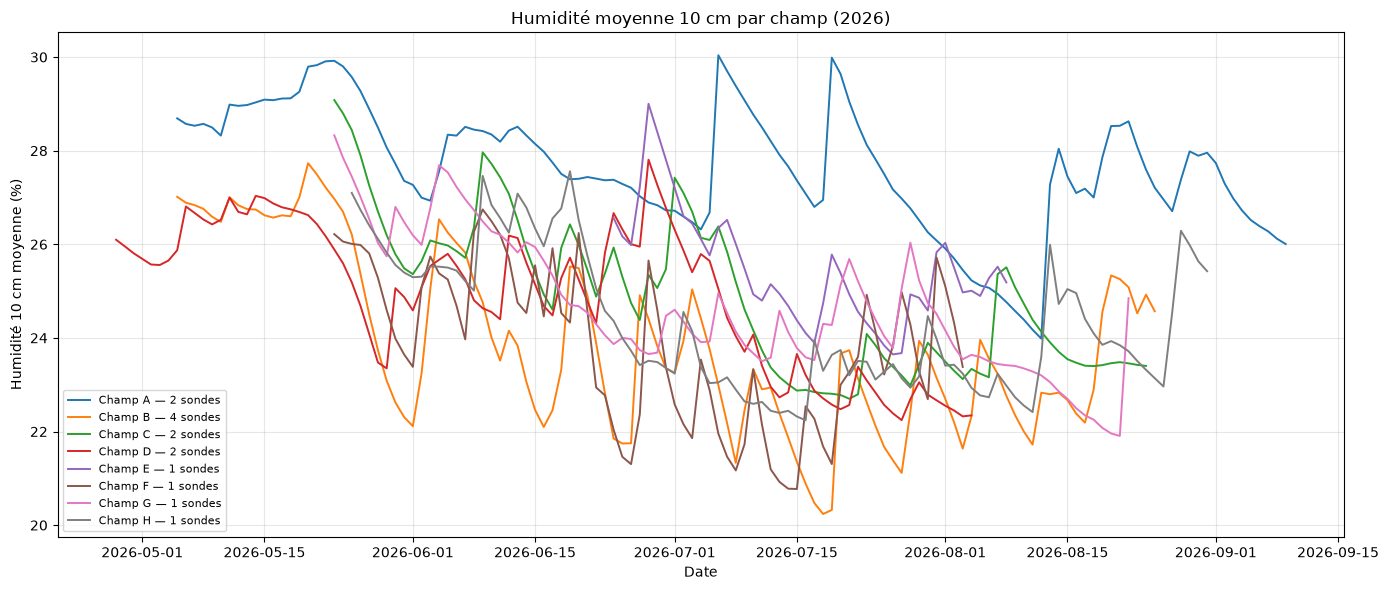


Nombre de mesures par champ / sonde :
field    no_serie
Champ A  887717      12140
         891481      12069
Champ B  893569      10556
         996039      10570
         996652      10571
         1003168     10677
Champ C  891515       8955
         996128       8948
Champ D  896077       9432
         997113       9418
Champ E  996025       3991
Champ F  895719       6898
Champ G  887587       8763
Champ H  892571       9408

Sonde 115260 (exclue des champs) : 2713 mesures horaires, 2026-05-05 → 2026-08-26, coordonnées absentes.


In [4]:
# ---------- Osiris 2026 : humidité moyenne 10 cm par champ + récap ----------
daily_mean26 = daily26.groupby(["date", "field"])["humidity_10cm"].mean().reset_index()
n_sonde26 = sub26.groupby("field")["no_serie"].nunique()

plt.figure(figsize=(14, 6))
for j, field in enumerate(sorted(daily_mean26["field"].unique())):
    g = daily_mean26[daily_mean26["field"] == field]
    plt.plot(g["date"], g["humidity_10cm"], linewidth=1.4, label=f"{field} — {n_sonde26[field]} sondes")
plt.xlabel("Date"); plt.ylabel("Humidité 10 cm moyenne (%)")
plt.title("Humidité moyenne 10 cm par champ (2026)")
plt.legend(loc="best", fontsize=8); plt.tight_layout(); plt.grid(True, alpha=0.3)
plt.show()

print("\nNombre de mesures par champ / sonde :")
print(sub26.groupby(["field", "no_serie"]).size().to_string())

g115 = df26[df26["no_serie"] == 115260].set_index("timestamp").sort_index()
print(f"\nSonde 115260 (exclue des champs) : {len(g115)} mesures horaires, "
      f"{g115.index.min():%Y-%m-%d} → {g115.index.max():%Y-%m-%d}, coordonnées absentes.")